In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import gzip
import json

import matplotlib
import pickle

import torch

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, r2_score, mean_squared_error, precision_score, recall_score, roc_curve

import sys
sys.path.append('..')
from sepsis_models.models.contrastive import *
from sepsis_models.models.treatment_triplets import *
from sepsis_models.preprocessing.dataset import *
from sepsis_models.derived_information.neighbors import get_nearest_neighbors

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Update these
data_dir = "../data/mimiciv"
validation_paths = ['../data/eicu'] # , '../data/ehrshot']
model_dir = "triplet_model_checkpoints"
if not os.path.exists(model_dir): os.mkdir(model_dir)

In [3]:
AS_IS_COLUMNS = []
BINARY_COLUMNS = []
LOG_NORM_COLUMNS = [
    "SpO2", "BUN", "Creatinine", "AST", "ALT", 
    "Total Bili", "Direct Bili", "INR",
    "Input Last 4 h", "Input Last 24 h", "Output Last 4 h", "Output Last 24 h",
    "Dopamine", "Epinephrine", "Norepinephrine", "Vasopressin", "Phenylephrine"
]

COMORBIDITIES = [
    'congestive_heart_failure', 'cardiac_arrhythmias', 'valvular_disease',
    'pulmonary_circulation', 'peripheral_vascular', 'hypertension',
    'paralysis', 'other_neurological', 'chronic_pulmonary',
    'diabetes_uncomplicated', 'diabetes_complicated', 'hypothyroidism',
    'renal_failure', 'liver_disease', 'peptic_ulcer',
    'aids', 'lymphoma', 'metastatic_cancer',
    'solid_tumor', 'rheumatoid_arthritis', 'coagulopathy',
    'obesity', 'weight_loss', 'fluid_electrolyte',
    'blood_loss_anemia', 'deficiency_anemias', 'alcohol_abuse',
    'drug_abuse', 'psychoses', 'depression'
]

EXCLUDE_COLUMNS = []

def format_states(df, scaler=None, all_columns=None):
    global BINARY_COLUMNS, LOG_NORM_COLUMNS, EXCLUDE_COLUMNS
    df = df.rename(columns={c: c.replace("Model:", "") for c in df.columns})
    df = df.assign(timestep=df.timestep.astype('datetime64[us]').astype(int) / 10**6)
    dummies = pd.get_dummies(df, 
                        columns=[c for c in df.columns 
                                if pd.api.types.is_object_dtype(df[c].dtype) 
                                or pd.api.types.is_string_dtype(df[c].dtype) 
                                or isinstance(df[c].dtype, pd.CategoricalDtype)])
    if all_columns is not None:
        dummies = dummies.assign(**{c: np.zeros(len(dummies), dtype=np.uint8)
                                    for c in all_columns if c not in dummies.columns})
    if scaler is None:
        EXCLUDE_COLUMNS = []
        # EXCLUDE_COLUMNS = [c for c in dummies.columns
        #                    if c.endswith("Present")]
        dummies = dummies.drop(columns=EXCLUDE_COLUMNS)
        AS_IS_COLUMNS = ["id", "timestep"]
        BINARY_COLUMNS = ["Invasive Ventilation", "Non-invasive Ventilation",
                 *[c for c in dummies.columns 
                   if "_" in c or 
                   " Present" in c or 
                   c.endswith("Current") or 
                   c.endswith("Ever") or 
                   (c.startswith("Positive") and c.endswith("Culture")) or 
                   c in COMORBIDITIES]]
        
        scaler = DataNormalization(dummies,
                                      as_is_columns=AS_IS_COLUMNS,
                                      binary_columns=BINARY_COLUMNS,
                                      log_norm_columns=LOG_NORM_COLUMNS,
                                      norm_columns=[c for c in dummies.columns if c not in BINARY_COLUMNS + AS_IS_COLUMNS + LOG_NORM_COLUMNS])
        return scaler.transform(dummies).fillna(0).assign(id=dummies['id'], timestep=dummies['timestep']), scaler, dummies.columns
    return scaler.transform(dummies.drop(columns=[c for c in EXCLUDE_COLUMNS if c in dummies.columns])).fillna(0).assign(id=dummies['id'], timestep=dummies['timestep'])
    
inputs_df, normalizer, all_cols = format_states(pd.read_csv(os.path.join(data_dir, "extracted_model_features.csv")))
inputs_df = inputs_df.clip(-10, 10).assign(id=inputs_df['id'], timestep=inputs_df['timestep'])
target_df = pd.read_csv(os.path.join(data_dir, "predictive_targets.csv")).fillna(0)
target_df = target_df.assign(timestep=target_df.timestep.astype('datetime64[us]').astype(int) / 10**6)
treatment_df = pd.read_csv(os.path.join(data_dir, "treatments.csv")).fillna(0)
treatment_df = treatment_df.assign(timestep=treatment_df.timestep.astype('datetime64[us]').astype(int) / 10**6)

# target_scaler = DataNormalization(target_df, as_is_columns=['id', 'timestep', 'VasopressorNeed', 'Mortality'], norm_columns=['DischargeTime', 'SOFA'])
# target_df = target_scaler.transform(target_df.fillna(0))
print("Excluding columns:", EXCLUDE_COLUMNS)

# filter to a maximum of 14 days per patient (84 timesteps), minimum of 12 hours (3 timesteps)
max_steps = 14 * 6
print('max steps:', max_steps)
min_days = 0.5
time_res = 4
inputs_mask = ((inputs_df['timestep'].groupby(inputs_df['id']).transform(lambda g: np.argsort(g)) < max_steps)
              & (pd.Series(np.ones(len(inputs_df)), index=inputs_df.index).groupby(inputs_df['id']).transform("sum") >= min_days * 24 / time_res))

print("Before:", len(inputs_df))
inputs_df = inputs_df[inputs_mask].reset_index(drop=True)
target_df = target_df[inputs_mask].reset_index(drop=True)
treatment_df = treatment_df[inputs_mask].reset_index(drop=True)

print("After:", len(inputs_df))

Excluding columns: []
max steps: 84
Before: 1397241
After: 1388991


In [4]:
# Validation datasets
validation_datasets = []

train_ids, test_ids = train_test_split(inputs_df['id'].unique(), test_size=0.2)
validation_datasets.append((
    "mimiciv",
    inputs_df[inputs_df['id'].isin(test_ids)],
    target_df[target_df['id'].isin(test_ids)],
    treatment_df[treatment_df['id'].isin(test_ids)],
))
inputs_df = inputs_df[inputs_df['id'].isin(train_ids)]
target_df = target_df[target_df['id'].isin(train_ids)]
treatment_df = treatment_df[treatment_df['id'].isin(train_ids)]

for path in validation_paths:
    print(path)
    val_X = format_states(pd.read_csv(os.path.join(path, "extracted_model_features.csv")), normalizer, all_cols)
    val_y = pd.read_csv(os.path.join(path, "predictive_targets.csv")).fillna(0)
    val_tx = pd.read_csv(os.path.join(path, "treatments.csv")).fillna(0)
    print(len(val_X), len(val_y), len(val_tx))
    
    val_X = val_X.clip(-10, 10).assign(id=val_X['id'], timestep=val_X['timestep'])
    val_y = val_y.assign(timestep=val_y.timestep.astype('datetime64[us]').astype(int) / 10**6)
    val_tx = val_tx.assign(timestep=val_tx.timestep.astype('datetime64[us]').astype(int) / 10**6)
    # val_y = target_scaler.transform(val_y.fillna(0))

    # filter to a maximum of 14 days per patient (84 timesteps), minimum of 12 hours (3 timesteps)
    val_mask = ((val_X['timestep'].groupby(val_X['id']).transform(lambda g: np.argsort(g)) < max_steps)
                & (pd.Series(np.ones(len(val_X)), index=val_X.index).groupby(val_X['id']).transform("sum") >= min_days * 24 / time_res))

    print("Before:", len(val_X))
    val_X = val_X[val_mask].reset_index(drop=True)
    val_y = val_y[val_mask].reset_index(drop=True)
    val_tx = val_tx[val_mask].reset_index(drop=True)
    print("After:", len(val_X))
    validation_datasets.append((os.path.basename(path), val_X, val_y, val_tx))

../data/eicu


/var/folders/gj/cy6x5zxs74j__yh6fwqs72500000gp/T/ipykernel_56680/3428598666.py:17: DtypeWarning: Columns (188) have mixed types. Specify dtype option on import or set low_memory=False.
  val_X = format_states(pd.read_csv(os.path.join(path, "extracted_model_features.csv")), normalizer, all_cols)


334268 334268 334268
Before: 334268
After: 333766


In [5]:
import itertools

parameter_sets = [
    *(dict(zip(['architecture', 'nencoder', 'nhid', 'nembed', 'lr', 'dropout', 'lr_decay', 
                'batch_size', 'corruption_rate', 'triplet_margin', 'neg_same_traj_prob'],
               x))
      for x in itertools.product(
          ['dense'],
          [4],
          [128],
          [32],
          [1e-3],
          [0.1],
          [0.98],
          [32],
          [0.1, 0.3, 0.5],
          [0.1, 1.0, 5.0],
          [0.2, 0.5, 0.8]
      )),
    # *(dict(zip(['architecture', 'nencoder', 'nhid', 'nembed', 'lr', 'dropout', 'lr_decay', 
    #             'batch_size', 'loss_weighting', 'past_value_reconstruction', 'first_value_reconstruction'],
    #            x))
    #   for x in itertools.product(
    #       ['rnn'],
    #       [2, 4],
    #       [32, 64, 128],
    #       [8, 16, 32, 64],
    #       [1e-3],
    #       [0.1],
    #       [0.98],
    #       [32],
    #       ['none', 'unusualness', 'change'],
    #       [False, True],
    #       [False, True]
    #   )),
    *(dict(zip(['architecture', 'nencoder', 'nhid', 'nhead', 'nembed', 'lr', 'dropout', 'lr_decay', 
                'batch_size', 'corruption_rate', 'triplet_margin', 'neg_same_traj_prob'],
               x))
      for x in itertools.product(
          ['transformer'],
          [4],
          [128],
          [8],
          [32],
          [1e-3],
          [0.1],
          [0.98],
          [32],
          [0.1, 0.3, 0.5],
          [0.1, 1.0, 5.0],
          [0.2, 0.5, 0.8]
      )),
]
len(parameter_sets), parameter_sets[:5]

(54,
 [{'architecture': 'dense',
   'nencoder': 4,
   'nhid': 128,
   'nembed': 32,
   'lr': 0.001,
   'dropout': 0.1,
   'lr_decay': 0.98,
   'batch_size': 32,
   'corruption_rate': 0.1,
   'triplet_margin': 0.1,
   'neg_same_traj_prob': 0.2},
  {'architecture': 'dense',
   'nencoder': 4,
   'nhid': 128,
   'nembed': 32,
   'lr': 0.001,
   'dropout': 0.1,
   'lr_decay': 0.98,
   'batch_size': 32,
   'corruption_rate': 0.1,
   'triplet_margin': 0.1,
   'neg_same_traj_prob': 0.5},
  {'architecture': 'dense',
   'nencoder': 4,
   'nhid': 128,
   'nembed': 32,
   'lr': 0.001,
   'dropout': 0.1,
   'lr_decay': 0.98,
   'batch_size': 32,
   'corruption_rate': 0.1,
   'triplet_margin': 0.1,
   'neg_same_traj_prob': 0.8},
  {'architecture': 'dense',
   'nencoder': 4,
   'nhid': 128,
   'nembed': 32,
   'lr': 0.001,
   'dropout': 0.1,
   'lr_decay': 0.98,
   'batch_size': 32,
   'corruption_rate': 0.1,
   'triplet_margin': 1.0,
   'neg_same_traj_prob': 0.2},
  {'architecture': 'dense',
   'nen

In [6]:
def make_treatment_indexes(treatments):
    return treatments['FutureFluids'] * 3 + treatments['FutureVasopressors']

In [ ]:
task_types = {
    "Mortality": "classification",
    "DischargeTime": "regression",
    "VasopressorNeed": "classification",
    "SOFA": "regression"
}

loss_histories = []
downstream_task_metrics = []
trajectory_ids = inputs_df['id'].unique()
seed = 0
kfold = KFold(n_splits=3, shuffle=True, random_state=seed)
splits = list(kfold.split(trajectory_ids))
    
for i, param_set in enumerate(reversed(parameter_sets)):
    for trial, (train_idx, test_idx) in enumerate(splits):
        print(trajectory_ids[train_idx], trajectory_ids[test_idx])
        
        train_df = inputs_df[inputs_df['id'].isin(trajectory_ids[train_idx])]
        val_df = inputs_df[inputs_df['id'].isin(trajectory_ids[test_idx])]
        model_params = {k: v for k, v in param_set.items() if k not in ('batch_size',)}
        model_trainer = TripletContrastiveTrainer(
            train_df,
            val_df,
            val_df,
            make_treatment_indexes(treatment_df[treatment_df['id'].isin(trajectory_ids[train_idx])]),
            make_treatment_indexes(treatment_df[treatment_df['id'].isin(trajectory_ids[test_idx])]),
            make_treatment_indexes(treatment_df[treatment_df['id'].isin(trajectory_ids[test_idx])]),
            time_col='timestep',
            device=device,
            checkpoint_path=os.path.join(model_dir, f"contrastive_{i}_trial_{trial}.pt"),
            **model_params
        )
        print(i, sum(p.numel() for p in model_trainer.model.parameters()))
        losses = []
        model_trainer.fit(epochs=1, patience=10, batch_size=param_set['batch_size'], loss_callback=lambda t, v: losses.append((t, v)))
        loss_histories.append(np.array(losses))
        with open(os.path.join(model_dir, "losses.pkl"), "wb") as file:
            pickle.dump(loss_histories, file)
        
        task_inputs = model_trainer.encode(model_trainer.val_dataset)
        # Now evaluate on the validation datasets
        for val_name, val_X, val_y, val_tx in validation_datasets:
            val_inputs = model_trainer.encode(model_trainer.make_dataset(val_X, id_col='id', time_col='timestep', treatments=make_treatment_indexes(val_tx).values))

            for task, task_type in task_types.items():
                true = val_y[task]
                print(task)
                task_outputs = target_df.loc[target_df['id'].isin(trajectory_ids[test_idx]), task]
                clf = LogisticRegression(max_iter=10000) if task_type == 'classification' else LinearRegression()
                clf.fit(task_inputs, task_outputs)
                
                if task_type == "classification":
                    # choose threshold
                    fpr, tpr, thresholds = roc_curve(task_outputs, clf.predict_proba(task_inputs)[:,1])
                    opt_threshold = thresholds[np.argmax(tpr - fpr)]
            
                if task_type == "classification":
                    preds_prob = clf.predict_proba(val_inputs)[:,1]
                    preds = preds_prob >= opt_threshold
                    metrics = {
                        "accuracy": accuracy_score(true, preds),
                        "f1": f1_score(true, preds),
                        "precision": precision_score(true, preds),
                        "recall": recall_score(true, preds),
                        "auroc": roc_auc_score(true, preds_prob),
                    }
                else:
                    preds = clf.predict(val_inputs)
                    # inverse transform
                    metrics = {
                        "r2": r2_score(true, preds),
                        "mse": mean_squared_error(true, preds)
                    }
                downstream_task_metrics.append({
                    **param_set,
                    "dataset": val_name,
                    "task": task,
                    "trial": trial,
                    **metrics
                })
        os.remove(os.path.join(model_dir, f"contrastive_{i}_trial_{trial}.pt"))
        with open(os.path.join(model_dir, "task_metrics.pkl"), "wb") as file:
            pickle.dump(downstream_task_metrics, file)

[30000484 30000831 30001148 ... 39998622 39998871 39999301] [30001396 30001947 30003306 ... 39998012 39999172 39999552]
0 826272
Epoch 0


Loss: 3.791462: 100%|██████████| 467/467 [00:28<00:00, 16.61it/s]


New best: 3.791462429075221


100%|██████████| 350/350 [00:12<00:00, 28.79it/s]


Mortality


...

DischargeTime
VasopressorNeed


/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SOFA
[30001148 30001396 30001555 ... 39998622 39999172 39999552] [30000484 30000831 30001446 ... 39995735 39998871 39999301]
0 826272
Epoch 0


5.454332:   1%|          | 8/933 [00:01<03:49,  4.02it/s]


KeyboardInterrupt: 

In [9]:
pd.DataFrame(downstream_task_metrics)[['task', 'dataset', 'auroc', 'mse']]

,task,dataset,auroc,mse
0,Mortality,mimiciv,0.770806,NaN
1,DischargeTime,mimiciv,NaN,10165.861413
2,VasopressorNeed,mimiciv,0.910473,NaN
3,SOFA,mimiciv,NaN,6.763436
4,Mortality,eicu,0.587579,NaN
5,DischargeTime,eicu,NaN,12711.732135
6,VasopressorNeed,eicu,0.823163,NaN
7,SOFA,eicu,NaN,5.867997


In [30]:
with open("contrastive_model_checkpoints/task_metrics.pkl", "rb") as file:
    results = pd.DataFrame(pickle.load(file))
results = results[[c for c in results.columns if len(results[c].unique()) != 1]]
acc_metrics = ["accuracy", "f1", "precision", "recall", "auroc", "r2", "mse"]
results = results.groupby([c for c in results.columns if c not in ("trial", *acc_metrics)]).agg({c: 'mean' for c in acc_metrics}).reset_index()
results

for dataset in ['mimiciv', 'eicu']:
    dataset_results = results[results['dataset'] == dataset]
    for task in ["Mortality", "VasopressorNeed"]:
        print(task)
        print(dataset_results[dataset_results['task'] == task].sort_values('auroc', ascending=False).head(5)[[*[c for c in results.columns if c not in (*acc_metrics, 'dataset', 'task')], 'auroc']])
    for task in ["SOFA", "DischargeTime"]:
        print(task)
        print(dataset_results[dataset_results['task'] == task].sort_values('r2', ascending=False).head(5)[[*[c for c in results.columns if c not in (*acc_metrics, 'dataset', 'task')], 'r2']])

Mortality
    architecture  nhead  nembed  corruption_rate  infonce_temperature  \
125  transformer    8.0      64              0.6                 0.01   
29   transformer    8.0      32              0.4                 0.01   
61   transformer    8.0      32              0.6                 0.07   
53   transformer    8.0      32              0.6                 0.01   
101  transformer    8.0      64              0.4                 0.01   

        auroc  
125  0.769250  
29   0.766576  
61   0.765335  
53   0.763854  
101  0.763764  
VasopressorNeed
    architecture  nhead  nembed  corruption_rate  infonce_temperature  \
127  transformer    8.0      64              0.6                 0.01   
63   transformer    8.0      32              0.6                 0.07   
135  transformer    8.0      64              0.6                 0.07   
103  transformer    8.0      64              0.4                 0.01   
111  transformer    8.0      64              0.4                 0.07   



In [10]:
trajectory_ids = inputs_df['id'].unique()

best_param_set = param_set
# best_param_set = {'architecture': 'transformer', 
#                   'nencoder': 4, 
#                   'nhead': 8, 
#                   'nhid': 128, 
#                   'nembed': 32, 
#                   'lr': 0.001, 
#                   'dropout': 0.1, 
#                   'lr_decay': 0.98, 
#                   'corruption_rate': 0.5,
#                   'mask_prob': 0.1,
#                   'infonce_temperature': 0.01,
#                   'same_trajectory_contrast_lambda': 0.1,
#                   'other_trajectory_contrast_lambda': 0.1}
final_train_ids, final_val_ids = train_test_split(trajectory_ids, test_size=0.1, random_state=0)
train_df = inputs_df[inputs_df['id'].isin(final_train_ids)]
val_df = inputs_df[inputs_df['id'].isin(final_val_ids)]
model_trainer = TripletContrastiveTrainer(
    train_df,
    val_df,
    val_df,
    make_treatment_indexes(treatment_df[treatment_df['id'].isin(final_train_ids)]),
    make_treatment_indexes(treatment_df[treatment_df['id'].isin(final_val_ids)]),
    make_treatment_indexes(treatment_df[treatment_df['id'].isin(final_val_ids)]),
    time_col='timestep',
    device='cpu',
    checkpoint_path=os.path.join(model_dir, f"contrastive_0_trial_0.pt"),
    **{k: v for k, v in best_param_set.items() if k != 'batch_size'}
)

# model_trainer.fit(epochs=3, patience=200, batch_size=32)
model_trainer.load_checkpoint()

FileNotFoundError: [Errno 2] No such file or directory: 'triplet_model_checkpoints/contrastive_0_trial_0.pt'

In [13]:
task_types = {
    "Mortality": "classification",
    "DischargeTime": "regression",
    "VasopressorNeed": "classification",
    "SOFA": "regression"
}

task_inputs = model_trainer.encode(model_trainer.val_dataset)
# Now evaluate on the validation datasets
for val_name, val_X, val_y, val_tx in validation_datasets:
    val_inputs = model_trainer.encode(model_trainer.make_dataset(val_X, id_col='id', time_col='timestep', treatments=make_treatment_indexes(val_tx).values))

    for task, task_type in task_types.items():
        true = val_y[task]
        task_outputs = target_df.loc[target_df['id'].isin(final_val_ids), task]
        clf = LogisticRegression() if task_type == 'classification' else LinearRegression()
        clf.fit(task_inputs, task_outputs)
        
        if task_type == "classification":
            # choose threshold
            fpr, tpr, thresholds = roc_curve(task_outputs, clf.predict_proba(task_inputs)[:,1])
            opt_threshold = thresholds[np.argmax(tpr - fpr)]
    
        if task_type == "classification":
            preds_prob = clf.predict_proba(val_inputs)[:,1]
            preds = preds_prob >= opt_threshold
            metrics = {
                "accuracy": accuracy_score(true, preds),
                "f1": f1_score(true, preds),
                "precision": precision_score(true, preds),
                "recall": recall_score(true, preds),
                "auroc": roc_auc_score(true, preds_prob),
            }
        else:
            preds = clf.predict(val_inputs)
            # inverse transform
            metrics = {
                "r2": r2_score(true, preds),
                "mse": mean_squared_error(true, preds)
            }
        print(task, val_name, metrics)

100%|██████████| 350/350 [00:11<00:00, 31.56it/s]
/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Mortality mimiciv {'accuracy': 0.7077527171751502, 'f1': 0.4698551789274845, 'precision': 0.368085171977926, 'recall': 0.6494062188378207, 'auroc': 0.7535479009549038}
DischargeTime mimiciv {'r2': 0.20074199370640122, 'mse': 9297.09480460559}


/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VasopressorNeed mimiciv {'accuracy': 0.8526578781808847, 'f1': 0.6798494740232702, 'precision': 0.5796192849200927, 'recall': 0.8219917170105248, 'auroc': 0.9092517516369362}
SOFA mimiciv {'r2': 0.11233272987616516, 'mse': 6.831171153957631}


100%|██████████| 388/388 [00:12<00:00, 31.72it/s]
/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Mortality eicu {'accuracy': 0.771103108165601, 'f1': 0.21956850406570505, 'precision': 0.5546266191876967, 'recall': 0.13687830350888366, 'auroc': 0.630654107776319}
DischargeTime eicu {'r2': 0.0508494154198289, 'mse': 10896.68452958763}


/Users/vsivaram/miniconda3/envs/sepsis-ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


VasopressorNeed eicu {'accuracy': 0.8648424345199931, 'f1': 0.6262149195853738, 'precision': 0.6678212922380885, 'recall': 0.5894887914762179, 'auroc': 0.8021045552209218}
SOFA eicu {'r2': 0.025678681153036287, 'mse': 5.503714981692797}


In [ ]:

task_types = {
    "Mortality": "classification",
    "DischargeTime": "regression",
    "VasopressorNeed": "classification",
    "SOFA": "regression"
}

train_encoded = model_trainer.encode(model_trainer.val_dataset)
train_treatment_idxs = make_treatment_indexes(treatment_df[treatment_df['id'].isin(final_val_ids)])
print(train_encoded.shape, train_treatment_idxs.shape)
train_neighb_train, _ = get_nearest_neighbors(train_encoded, 
                                                            train_encoded, 
                                                            val_df["id"].values, reference_identical=True,
                                                            stratify=(train_treatment_idxs, train_treatment_idxs))

for val_name, val_X, val_y, val_tx in validation_datasets:
    if len(val_X) > 10000:
        val_sample_ids = np.random.choice(val_X['id'].unique(), size=1000)
        val_y = val_y[val_X["id"].isin(val_sample_ids)]
        val_tx = val_tx[val_X["id"].isin(val_sample_ids)]
        val_X = val_X[val_X["id"].isin(val_sample_ids)]
        
    val_inputs = model_trainer.encode(model_trainer.make_dataset(val_X, id_col='id', time_col='timestep'))
    val_treatment_idxs = make_treatment_indexes(val_tx)
    val_neighb_train, _ = get_nearest_neighbors(val_inputs, 
                                                train_encoded, 
                                                val_df["id"].values, 
                                                stratify=(val_treatment_idxs, train_treatment_idxs))

    for task, task_type in task_types.items():
        true = val_y[task].values
        print(task)
        task_outputs = target_df.loc[target_df['id'].isin(final_val_ids), task].values
        prob_comparisons = np.zeros(len(val_inputs))
        for i in range(len(val_inputs)):
            prob_comparisons[i] = task_outputs[val_neighb_train[i][val_neighb_train[i] >= 0]].mean()
        
        if task_type == "classification":
            # choose threshold
            sample_indexes = np.random.choice(len(task_outputs), size=1000)
            sample_probs = np.zeros(len(sample_indexes))
            for i, idx in enumerate(sample_indexes):
                sample_probs[i] = task_outputs[train_neighb_train[i][train_neighb_train[i] >= 0]].mean()
            fpr, tpr, thresholds = roc_curve(task_outputs[sample_indexes], sample_probs)
            opt_threshold = thresholds[np.argmax(tpr - fpr)]
    
        if task_type == "classification":
            preds_prob = prob_comparisons
            preds = prob_comparisons >= opt_threshold
            metrics = {
                "accuracy": accuracy_score(true, preds),
                "f1": f1_score(true, preds),
                "precision": precision_score(true, preds),
                "recall": recall_score(true, preds),
                "auroc": roc_auc_score(true, preds_prob),
            }
        else:
            preds = prob_comparisons
            metrics = {
                "r2": r2_score(true, preds),
                "mse": mean_squared_error(true, preds)
            }
        print(val_name, task, metrics)


100%|██████████| 140/140 [00:04<00:00, 28.67it/s]


(112027, 128) (112027,)
stratify value 0
Training index


100%|██████████| 59461/59461 [00:10<00:00, 5561.23it/s]


46095 rows with insufficient neighbors


100%|██████████| 46095/46095 [00:09<00:00, 4883.96it/s]


...

11 rows with insufficient neighbors


100%|██████████| 11/11 [00:00<00:00, 4562.63it/s]


6 rows with insufficient neighbors


100%|██████████| 6/6 [00:00<00:00, 2611.10it/s]


Mortality
eicu Mortality {'accuracy': 0.6767195767195767, 'f1': 0.3340080971659919, 'precision': 0.32265342960288806, 'recall': 0.34619109102646867, 'auroc': 0.5948284492663275}
DischargeTime
eicu DischargeTime {'r2': -0.1715587175864608, 'mse': 14684.188624061178}
VasopressorNeed
eicu VasopressorNeed {'accuracy': 0.7518896447467877, 'f1': 0.5377086120695725, 'precision': 0.40522182126936956, 'recall': 0.7989119062565391, 'auroc': 0.8495209103979782}
SOFA
eicu SOFA {'r2': 0.011124586071821208, 'mse': 5.536098114134543}


# Example: Plot SOFA Scores

In [ ]:
test_encoded = model_trainer.encode(model_trainer.val_dataset)
tsne = TSNE().fit_transform(test_encoded)

100%|██████████| 140/140 [00:04<00:00, 31.32it/s]


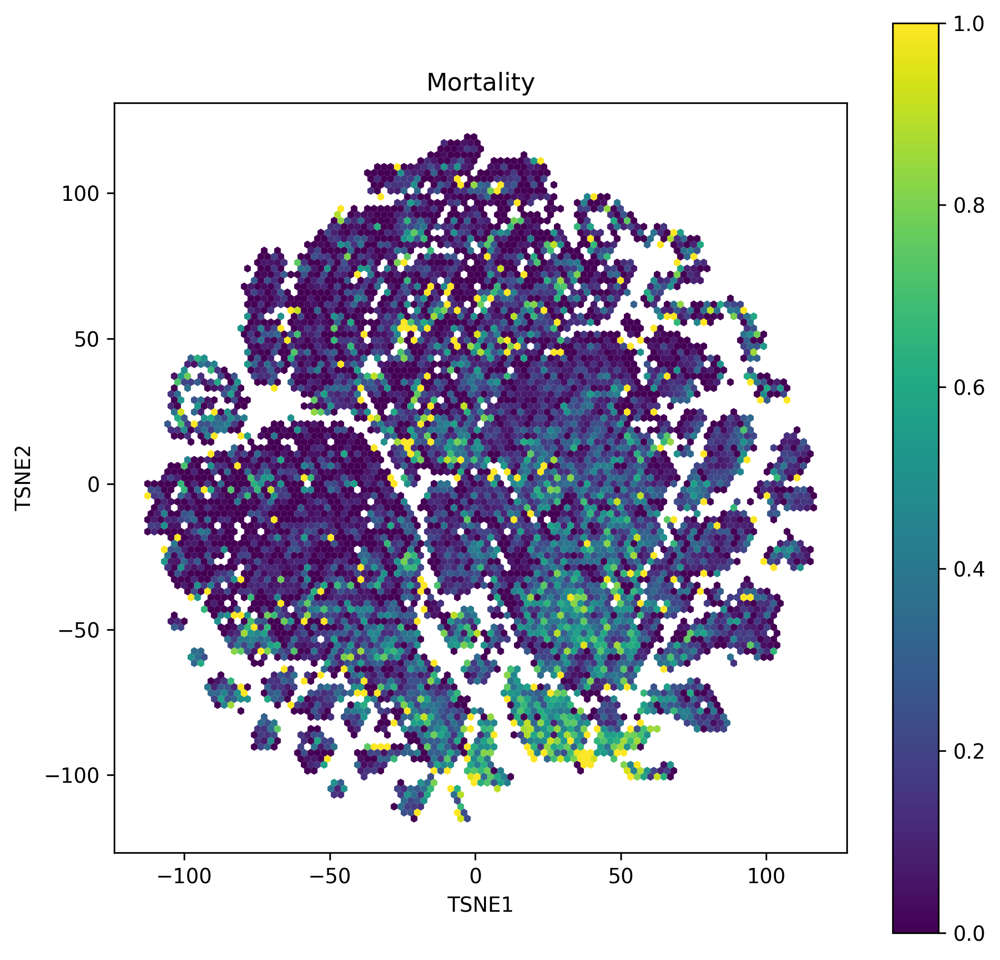

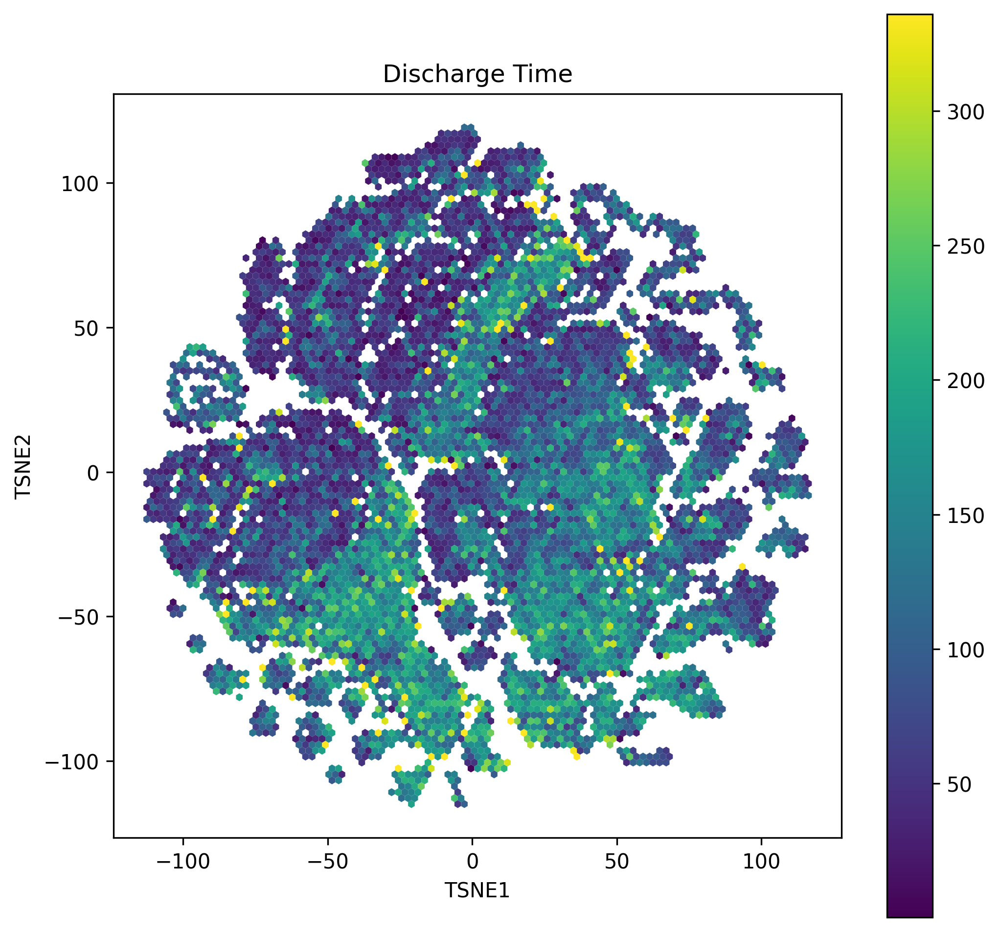

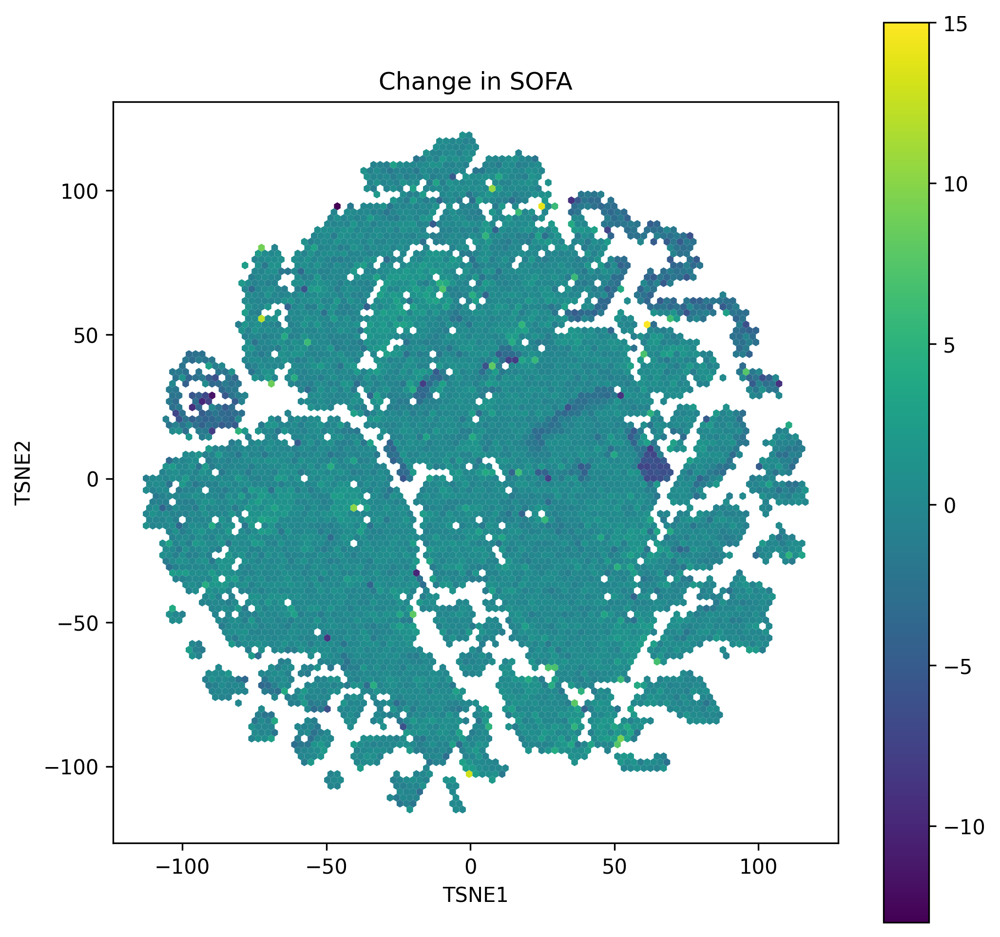

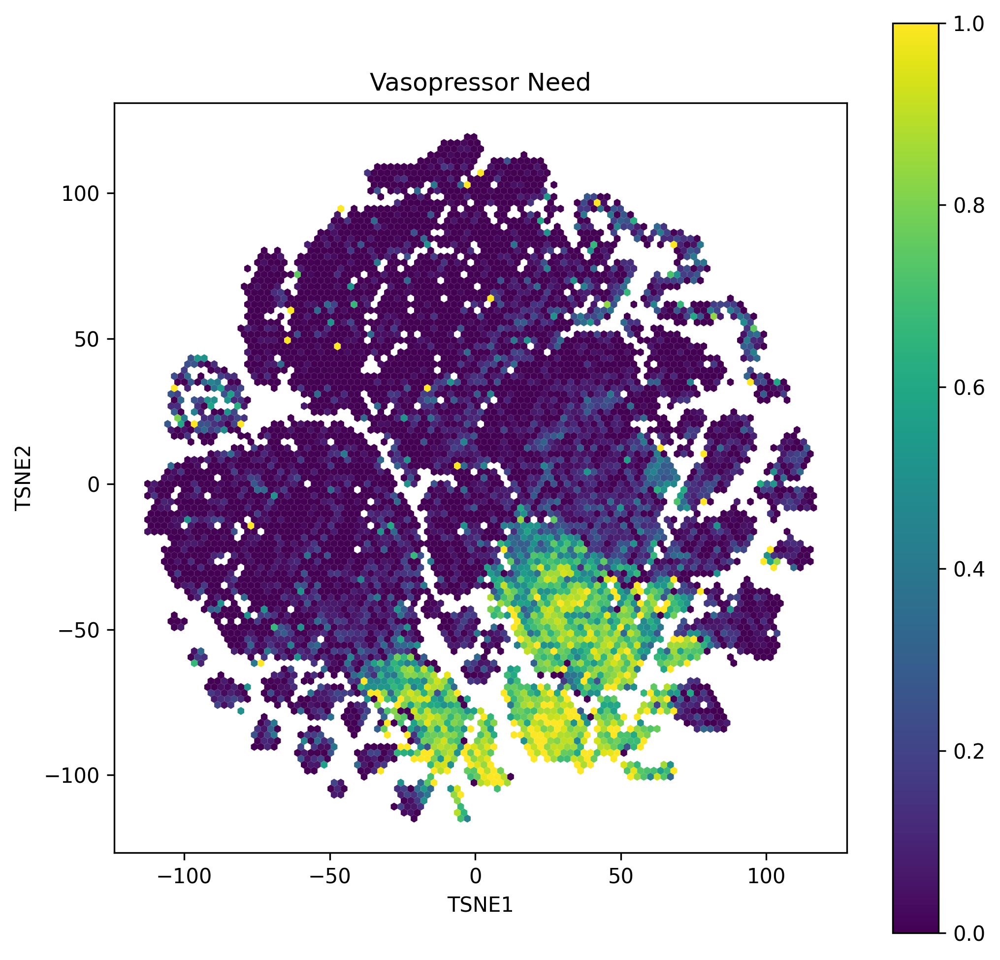

In [ ]:
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=target_df[target_df['id'].isin(final_val_ids)]['Mortality'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Mortality")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=target_df[target_df['id'].isin(final_val_ids)]['DischargeTime'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Discharge Time")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=target_df[target_df['id'].isin(final_val_ids)]['SOFA'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Change in SOFA")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=target_df[target_df['id'].isin(final_val_ids)]['VasopressorNeed'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Vasopressor Need")
plt.show()

In [41]:
# train_embs = model_trainer.encode(model_trainer.train_dataset)
# emb_idxs = np.random.choice(len(train_embs), size=1000, replace=False)
accs = {}
for feat in inputs_df.columns:
    if len(np.unique(inputs_df[feat])) == 2:
        if len(np.unique((inputs_df[inputs_df['id'].isin(final_train_ids)][feat] > 0).values[emb_idxs])) < 2: continue
        clf = LogisticRegression()
        clf.fit(train_embs[emb_idxs], (inputs_df[inputs_df['id'].isin(final_train_ids)][feat] > 0).values[emb_idxs])
        accs[feat] = roc_auc_score(inputs_df[inputs_df['id'].isin(final_val_ids)][feat].values > 0, 
                                   clf.predict_proba(test_encoded)[:,1])
print(sorted(accs.items(), key=lambda x: x[1], reverse=True)[:10])
r2s = {}
for feat in inputs_df.columns:
    if len(np.unique(inputs_df[feat])) > 2:
        clf = LinearRegression()
        clf.fit(train_embs[emb_idxs], inputs_df[inputs_df['id'].isin(final_train_ids)][feat].values[emb_idxs])
        r2s[feat] = r2_score(inputs_df[inputs_df['id'].isin(final_val_ids)][feat].values, 
                                   clf.predict(test_encoded))

print(sorted(r2s.items(), key=lambda x: x[1], reverse=True)[:10])

[('PaCO2 Present', 0.9999970994449331), ('Antimicrobial', 0.999997053741601), ('CO2 Calc Present', 0.9999968960710239), ('RASS Present', 0.9999967455472779), ('Arterial BE Present', 0.9999966302106109), ('Temperature C Present', 0.9999959564262153), ('DiaBP Present', 0.9999958386994945), ('SysBP Present', 0.9999919078305541), ('GCS Present', 0.9999880764873748), ('PaO2 Present', 0.9999875333342011)]
[('Output Last 4 h', 0.9715872656548189), ('Output Last 24 h', 0.9715872656548189), ('GCS Delta', 0.9574870901819241), ('RASS', 0.9573252943274876), ('RASS Delta', 0.9522708223395585), ('Input Last 24 h', 0.9513932216271809), ('CO2 Calc', 0.9452317795559435), ('Temperature C Delta', 0.9412403042965364), ('GCS', 0.9392768192336661), ('Temperature C', 0.935180979299059)]


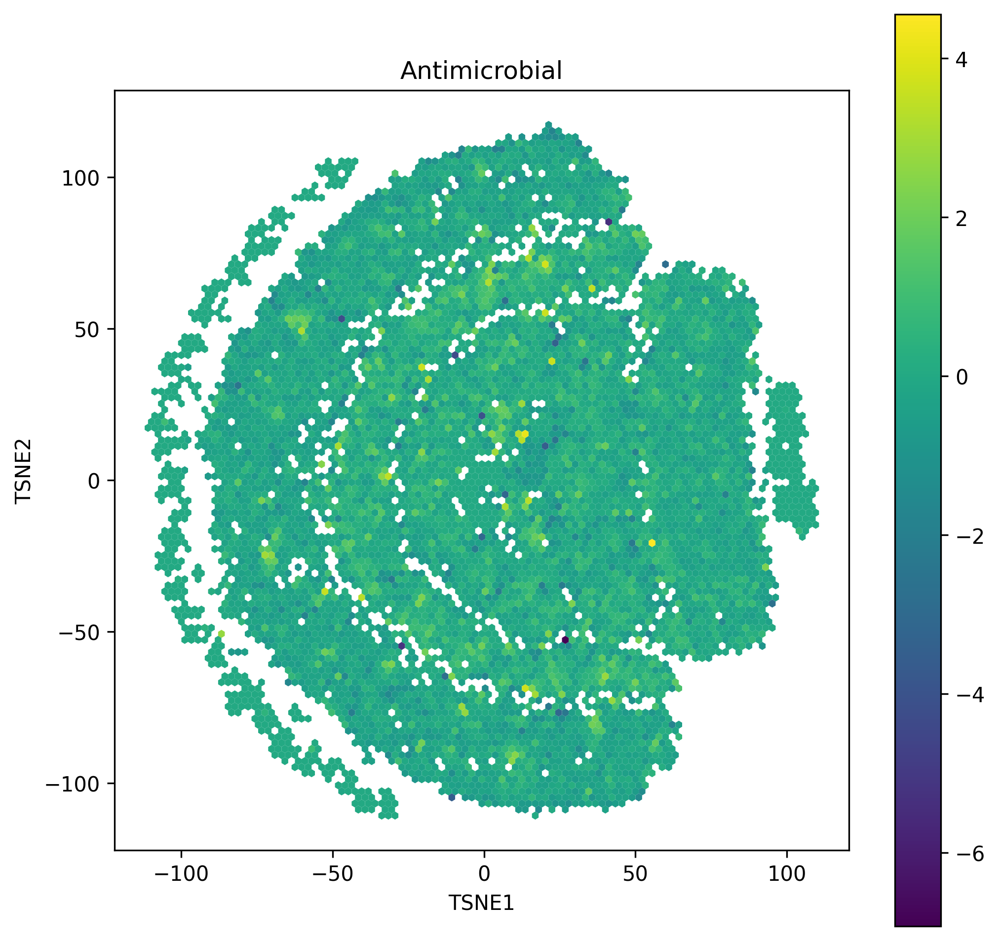

In [45]:
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=inputs_df[inputs_df['id'].isin(final_val_ids)]['Temperature C'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Antimicrobial")
plt.show()

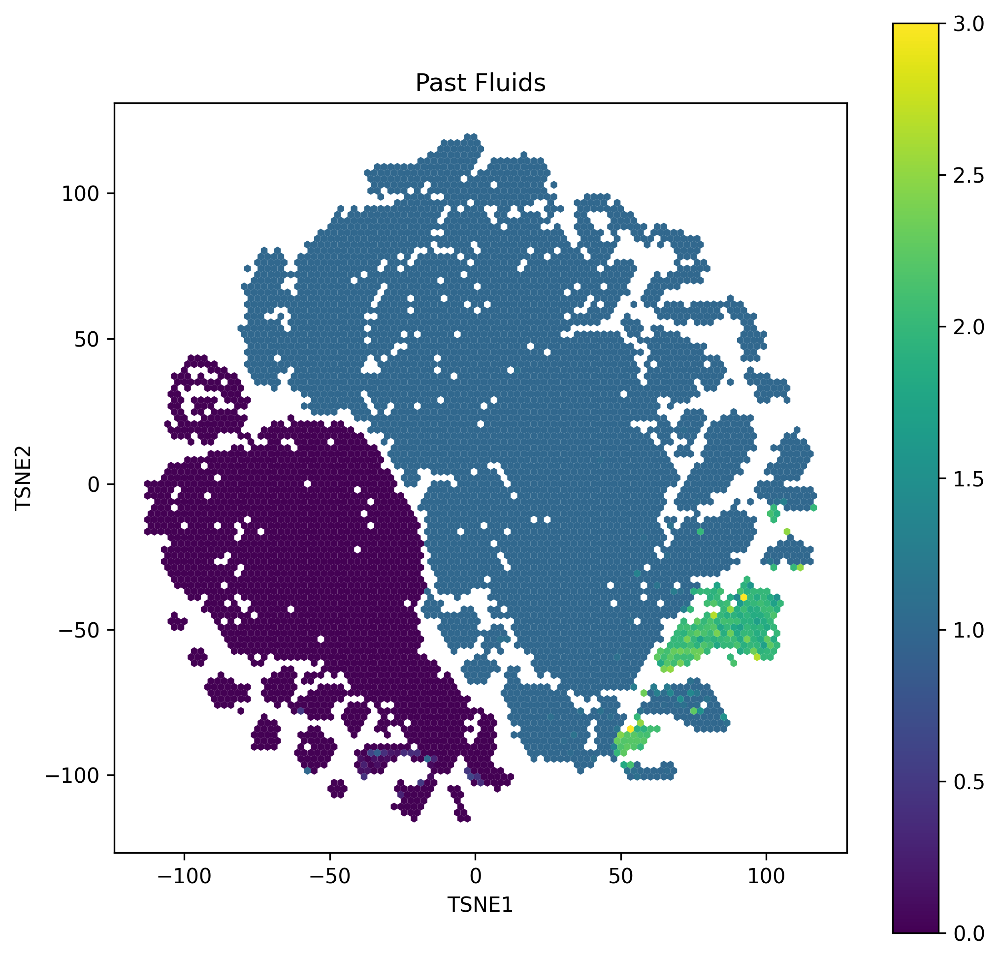

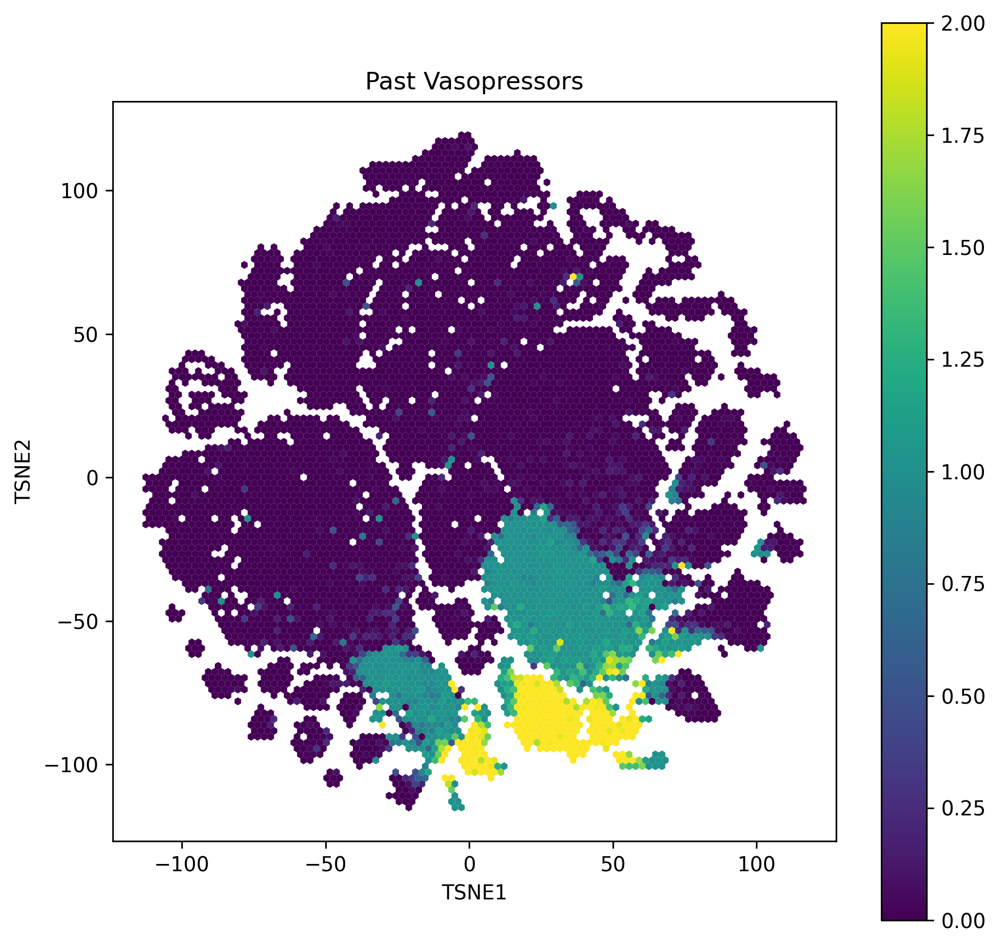

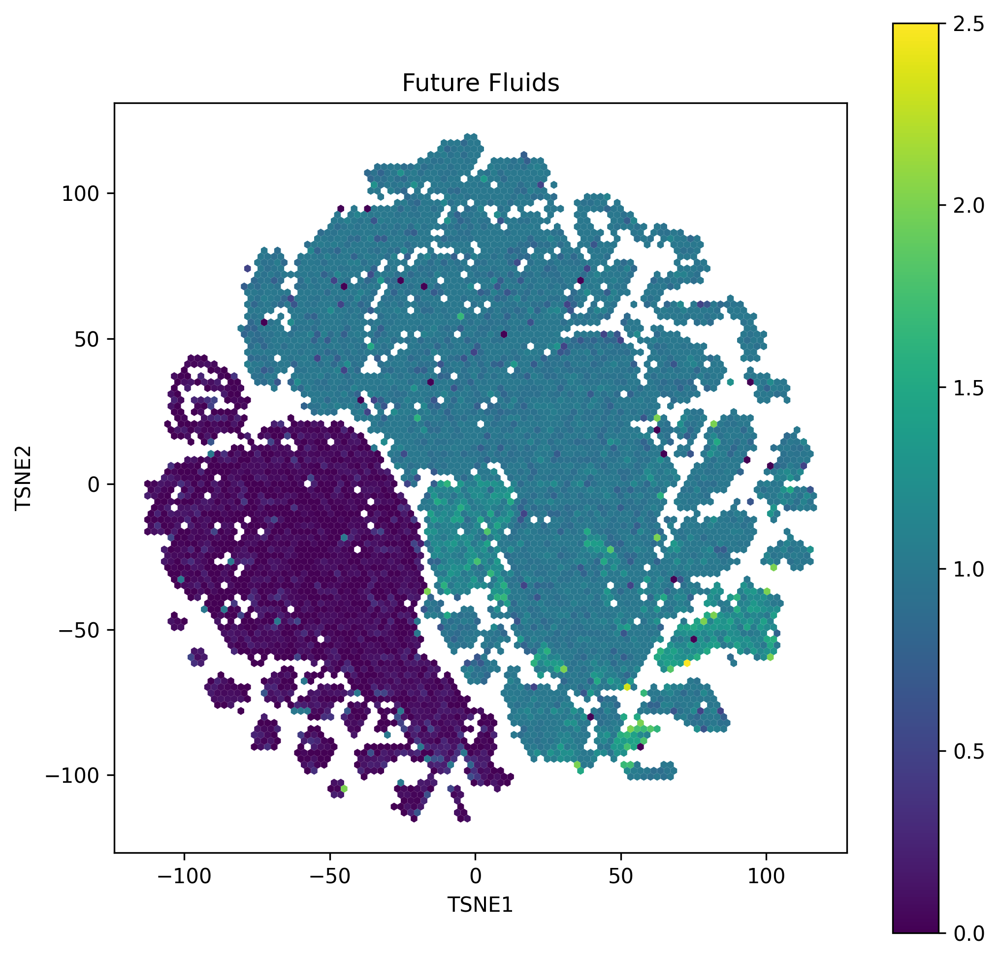

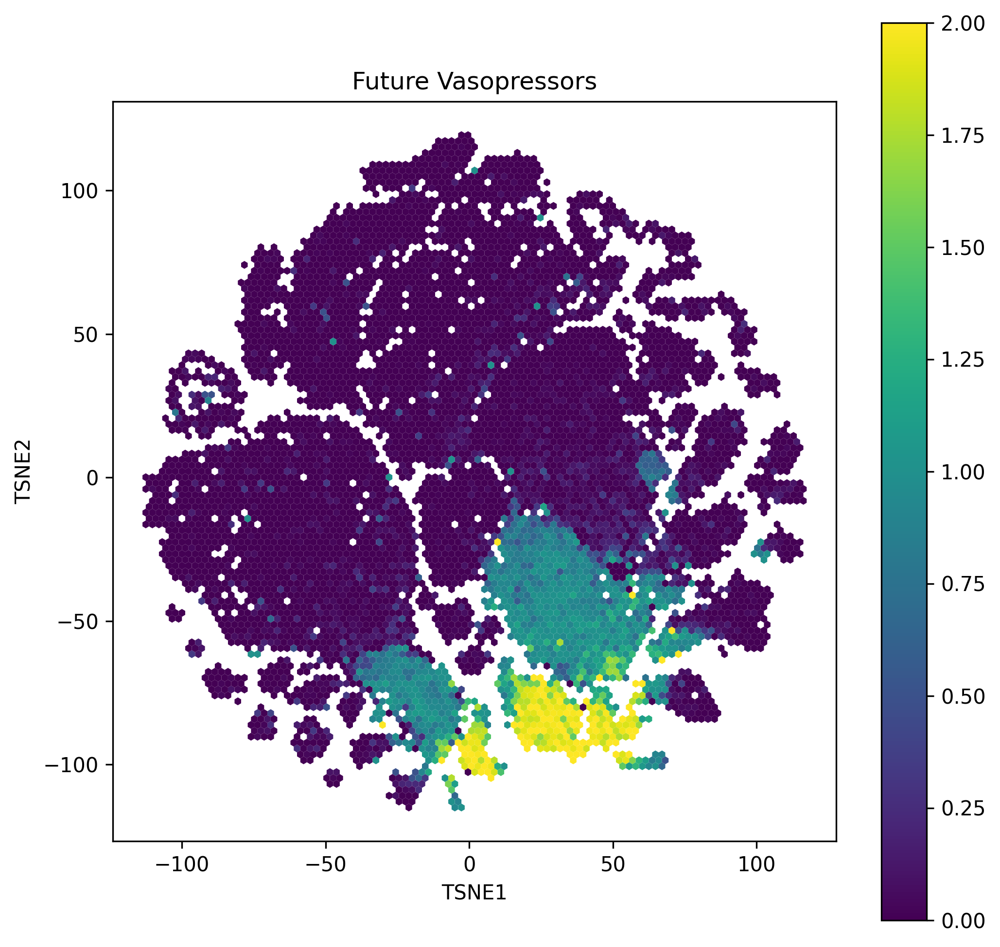

In [16]:
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=(treatment_df[treatment_df['id'].isin(final_val_ids)]['PastFluids'].values + 1) % 4, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Past Fluids")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=treatment_df[treatment_df['id'].isin(final_val_ids)]['PastVasopressors'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Past Vasopressors")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=(treatment_df[treatment_df['id'].isin(final_val_ids)]['FutureFluids'].values + 1) % 4, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Future Fluids")
plt.show()
plt.figure(figsize=(8, 8), dpi=300)
plt.hexbin(tsne[:,0], tsne[:,1], C=treatment_df[treatment_df['id'].isin(final_val_ids)]['FutureVasopressors'].values, lw=0)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.title("Future Vasopressors")
plt.show()

100%|██████████| 388/388 [00:12<00:00, 31.33it/s]


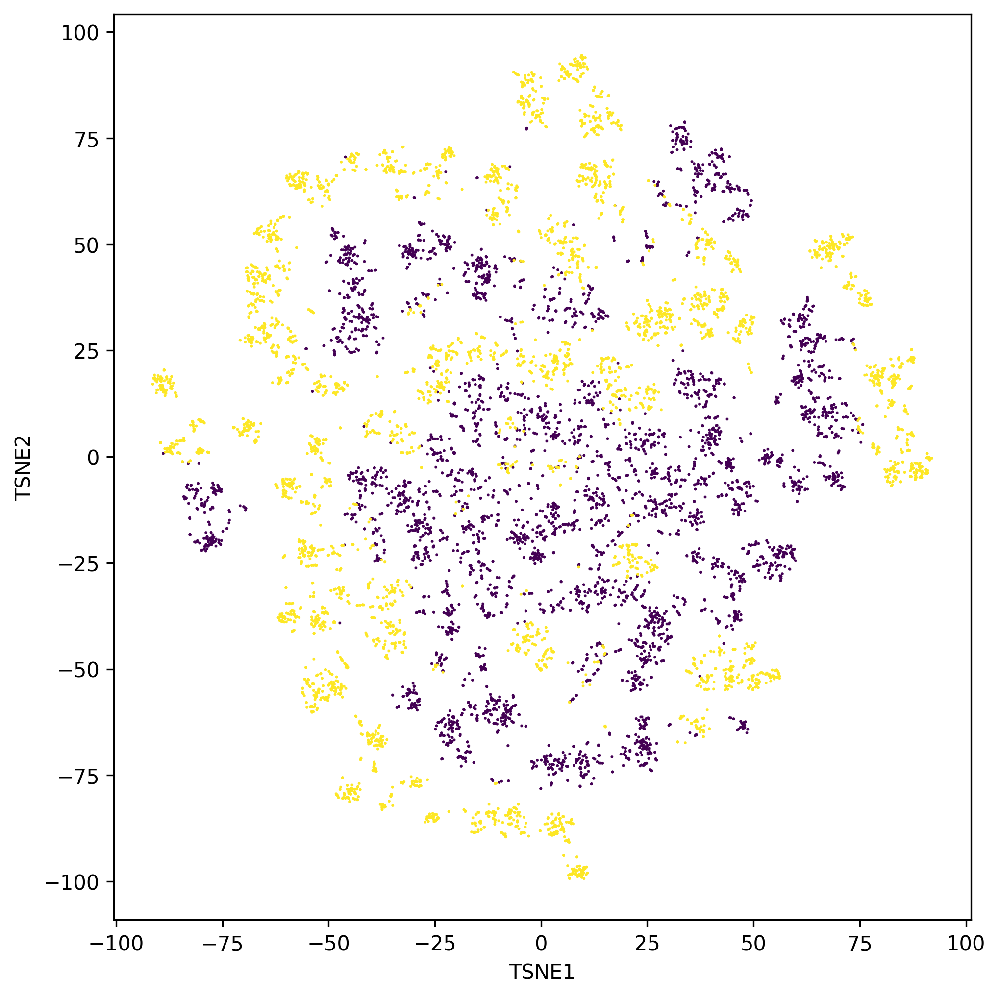

In [57]:

test_encoded = model_trainer.encode(model_trainer.test_dataset)[:5000]
other_encoded = model_trainer.encode(model_trainer.make_dataset(validation_datasets[1][1], time_col='timestep'))[-5000:]

tsne = TSNE().fit_transform(np.vstack([test_encoded, other_encoded]))
plt.figure(figsize=(8, 8), dpi=300)
plt.scatter(tsne[:,0], tsne[:,1], s=2, lw=0, c=np.concatenate([np.zeros(len(test_encoded)), np.ones(len(other_encoded))]))
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.show()

In [ ]:
# take a random sample to plot
sample_indexes = np.random.choice(len(test_encoded), size=50000)
encodings_mapped = TSNE(init='pca', verbose=True, metric='cosine').fit_transform(test_encoded[sample_indexes])

In [ ]:
severity_scores_test = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "test.csv"), index_col=0).iloc[:,-1].values
severity_scores_test = severity_scores_test[test_mask]

In [ ]:
plt.figure(figsize=(12, 6), dpi=300)
plt.subplot(121)
order = np.argsort(severity_scores_test[sample_indexes])
plt.scatter(encodings_mapped[order,0], encodings_mapped[order,1], s=2, lw=0, c=severity_scores_test[order], cmap='magma', vmax=20)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.subplot(122)
plt.hexbin(encodings_mapped[:,0], encodings_mapped[:,1], C=severity_scores_test[sample_indexes], lw=0, cmap='magma', vmax=20)
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.gca().set_aspect(1.0)
plt.colorbar()
plt.suptitle("SOFA Score")
plt.tight_layout()
plt.show()

# Case Selection


faiss is required to run (`conda install -c pytorch faiss-cpu=1.9.0`)

In [ ]:
severity_scores_train = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "train.csv"), index_col=0).iloc[:,-1].values
severity_scores_train = severity_scores_train[train_mask]
severity_scores_val = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "val.csv"), index_col=0).iloc[:,-1].values
severity_scores_val = severity_scores_val[val_mask]
severity_scores_test = pd.read_csv(os.path.join(data_dir, "outcomes", "sofa", "test.csv"), index_col=0).iloc[:,-1].values
severity_scores_test = severity_scores_test[test_mask]

severity_cutoffs = np.quantile(severity_scores_train, np.linspace(0, 1, 9))
print("SOFA score cutoffs:", severity_cutoffs)
train_severity_quantiles = np.digitize(severity_scores_train, severity_cutoffs[:-1]) - 1
val_severity_quantiles = np.digitize(severity_scores_val, severity_cutoffs[:-1]) - 1
test_severity_quantiles = np.digitize(severity_scores_test, severity_cutoffs[:-1]) - 1

In [ ]:
def create_treatments(split):
    treatments = pd.concat([
        pd.read_csv(os.path.join(data_dir, "treatments", "fluids", f"{split}.csv"), index_col=0).drop(columns=["id", "timestep"]),
        pd.read_csv(os.path.join(data_dir, "treatments", "vaso", f"{split}.csv"), index_col=0).drop(columns=["id", "timestep"]),
    ], axis=1)
    treatments.columns = ["fluid", "vaso"]
    treatments['vaso'] = treatments['vaso'].fillna(0).astype(int)
    treatments['fluid'] = treatments['fluid'].fillna(0).astype(int)
    return treatments

treatments_train = create_treatments('train')[train_mask]
treatments_test = create_treatments('test')[test_mask]

In [ ]:
# example: nearest neighbors of the validation set instances in the training set
neighborhoods_dir = os.path.join(data_dir, "neighborhoods")
if not os.path.exists(neighborhoods_dir): os.mkdir(neighborhoods_dir)

if not os.path.exists(os.path.join(neighborhoods_dir, "train_neighbors.pkl")):
    train_encoded = model_trainer.encode(split='train')
    test_encoded = model_trainer.encode(split='test')
    train_neighb_train, train_neighb_dist_train = get_nearest_neighbors(train_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    reference_identical=True,
                                                                    stratify=(train_severity_quantiles, train_severity_quantiles))
    test_neighb_train, test_neighb_dist_train = get_nearest_neighbors(test_encoded, 
                                                                    train_encoded, 
                                                                    train_df["id"].values, 
                                                                    stratify=(test_severity_quantiles, train_severity_quantiles))

    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "wb") as file:
        pickle.dump((train_neighb_train, train_neighb_dist_train), file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "wb") as file:
        pickle.dump((test_neighb_train, test_neighb_dist_train), file)
else:
    with open(os.path.join(neighborhoods_dir, "train_neighbors.pkl"), "rb") as file:
        train_neighb_train, train_neighb_dist_train = pickle.load(file)
    with open(os.path.join(neighborhoods_dir, "test_neighbors.pkl"), "rb") as file:
        test_neighb_train, test_neighb_dist_train = pickle.load(file)
    

In [ ]:
# Preprocess slicing variables
train_slicing_vars = pd.read_csv(os.path.join(data_dir, "slicing", "inputs_train.csv"), index_col=0)[train_mask].reset_index(drop=True)
eval_slicing_vars = pd.read_csv(os.path.join(data_dir, "slicing", "inputs_test.csv"), index_col=0)[test_mask].reset_index(drop=True)
COLUMNS_TO_DROP = [
    "Gender"
]
train_slicing_vars = train_slicing_vars.drop(columns=COLUMNS_TO_DROP)
eval_slicing_vars = eval_slicing_vars.drop(columns=COLUMNS_TO_DROP)

for c in eval_slicing_vars.columns:
    try:
        if len(np.unique(eval_slicing_vars[c])) == 2 and (np.unique(eval_slicing_vars[c]) == np.array([0, 1])).all():
            print(c)
            eval_slicing_vars[c] = eval_slicing_vars[c].astype(int).replace({0: 'No', 1: 'Yes'})
            train_slicing_vars[c] = train_slicing_vars[c].astype(int).replace({0: 'No', 1: 'Yes'})
    except: pass

eval_slicing_vars = eval_slicing_vars.fillna('Missing')
train_slicing_vars = train_slicing_vars.fillna('Missing')

# Identify Cases with High Abnormality

In [ ]:
RANGES_BY_SYSTEM = {
    "Cardiac": {
        "Lactic Acid": { "min": 0.5, "max": 1.6 },
        "Troponin": { "max": 1 }, # not sure what these units are
    },
    "Coags": {
        "PTT": { "min": 60, "max": 70 },
        "PT": { "min": 11, "max": 13.5 },
        "INR": { "min": 0.8, "max": 1.1 },
    },
    "ABGs": {
        "Arterial pH": { "min": 7.35, "max": 7.45 },
        "Arterial BE": { "min": -4, "max": 2 },
        "PaO2": { "min": 75, "max": 100 },
        "PaCO2": { "min": 35, "max": 45 },
        "Bicarbonate": { "min": 20, "max": 32 },
    },
    "ID": {
        "WBC Count": { "min": 4.5, "max": 11 },
    },
    "Hgb": {
        "Hemoglobin": { "male": { "min": 14.0, "max": 17.5 },
                        "female": { "min": 12.3, "max": 15.3 }},
        "Hematocrit": { "male": { "min": 41, "max": 50 },
                        "female": { "min": 36, "max": 48 }},
    },
    "Platelets": {
        "Platelet Count": { "min": 130, "max": 400 },
    },
    "Liver": {
        "AST": { "female": { "min": 9, "max": 25 }, "male": { "min": 10, "max": 40 } },
        "ALT": { "female": { "min": 7, "max": 30 }, "male": { "min": 10, "max": 55 } },
        "Total Bili": { "min": -1, "max": 5 },
        "Direct Bili": { "min": -1, "max": 2 },
    },
    "Chemistries": {
        "Potassium": { "min": 3.4, "max": 5 },
        "Sodium": { "min": 135, "max": 145 },
        "Chloride": { "min": 95, "max": 108 },
        "Glucose": { "min": 110, "max": 180 },
        "Ionized Ca": { "min": 1.1, "max": 1.4 },
    },
    "Renal": {
        "BUN": { "min": 8, "max": 25 },
        "Creatinine": {
            "female": { "min": 0.6, "max": 1.8 },
            "male": { "min": 0.8, "max": 2.4 },
          },
    },
    "Neuro": {
        "GCS Eye Opening": { "min": 3, "max": 6 },
        "GCS Motor Response": { "min": 3, "max": 7 },
        "GCS Verbal Response": { "min": 3, "max": 6 },
        "RASS": { "min": -3, "max": 2 }
    }
}

def _assign_bin_values(col_data, bin_spec):
    lower = bin_spec.get("min", np.quantile(col_data, 0.25))
    upper = bin_spec.get("max", np.quantile(col_data, 0.75))
    assert lower < upper, f"{bin_spec}"
    return np.digitize(col_data, [lower, upper]) != 1

EXTREME_VALUE_BIN_NAMES = {"normal": 0, "abnormal": 1}
def extreme_value_binning(col_name, norm_range, col_data, gender_data):
    if "female" in norm_range:
        return np.where(gender_data, 
                        _assign_bin_values(col_data, norm_range["female"]),
                        _assign_bin_values(col_data, norm_range["male"])), EXTREME_VALUE_BIN_NAMES
    return _assign_bin_values(col_data, norm_range), EXTREME_VALUE_BIN_NAMES

def get_abnormal_flags(states):
    abnormal_flags = []
    abnormal_flags_system = {}
    for system, system_ranges in RANGES_BY_SYSTEM.items():
        system_flags = np.vstack([
            np.logical_and(extreme_value_binning(lab_name, range_info, states[lab_name], states['gender_female'])[0],
                           states[f'{lab_name} Present'])
            for lab_name, range_info in system_ranges.items()
        ]).T
        abnormal_flags.append(pd.DataFrame(system_flags, columns=list(system_ranges.keys())))
        abnormal_flags_system[system] = system_flags.any(axis=1)
    abnormal_flags = pd.concat(abnormal_flags, axis=1)
    abnormal_flags_system = pd.DataFrame(abnormal_flags_system)
    return abnormal_flags, abnormal_flags_system

raw_test_states = pd.read_csv(os.path.join(data_dir, "model_features", "inputs_test.csv"), index_col=0)[test_mask].reset_index(drop=True)
abnormal_flags, abnormal_flags_system = get_abnormal_flags(raw_test_states)
abnormal_flags.mean(axis=0)

In [ ]:
matching_notes = pd.read_csv("../../AI-Clinician-MIMICIV/data/intermediates/patient_matched_notes.csv")
matching_notes = pd.merge(test_df[['id', 'timestep']], matching_notes.drop_duplicates('note_id'), left_on='id', right_on='icustayid', how='left')
note_contains_sepsis = matching_notes.groupby(['id', 'timestep']).agg({'target': lambda g: g.str.contains(r'sepsis|septic', case=False, regex=True).any()}).reset_index()
del matching_notes

cases_to_select = np.logical_and(
    np.logical_and(
        # interesting_masks.sum(axis=0) >= 4,
        test_neighb_dist_train[:,-1] <= np.quantile(test_neighb_dist_train[:,-1], 0.25),
        abnormal_flags.sum(axis=1) >= 5
    ),
    # abnormal_flags.sum(axis=1) >= 5,
    note_contains_sepsis['target']
)
print(cases_to_select.sum(), len(test_df['id'][cases_to_select].unique()))

cases_to_select = test_df[['id', 'timestep']][cases_to_select]
cases_to_select['id'] = cases_to_select['id'].astype(int)
cases_to_select.to_csv(os.path.join(data_dir, 'interesting_prediction_cases.csv'), index=False)